In [86]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [87]:
# y = 10 * X1 - 8 * X2 - 30
X1 = np.linspace(-10, 10, 100)
X2 = np.linspace(-10, 10, 100)

print(X1.shape, X2.shape)

(100,) (100,)


In [88]:
X1, X2 = np.meshgrid(X1, X2)
print(X1.shape, X2.shape)

(100, 100) (100, 100)


In [89]:
print(X1[0], X1[1], sep='\n')

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

In [90]:
X1_flat = X1.flatten()
X2_flat = X2.flatten()

print(X1_flat.shape, X2_flat.shape)

(10000,) (10000,)


In [91]:
print(X1_flat[1::100])

[-9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798
 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.7979798 -9.797

In [92]:
y = 10 * X1_flat + 80 * X2_flat - 30 + np.random.normal(0, 20, len(X1_flat))

In [93]:
print(y.shape)

(10000,)


In [94]:
print(y[:10])

[-896.54590701 -925.34682971 -916.2009716  -915.59562949 -915.52019272
 -935.16764074 -954.51042127 -905.36200518 -905.14335446 -946.002064  ]


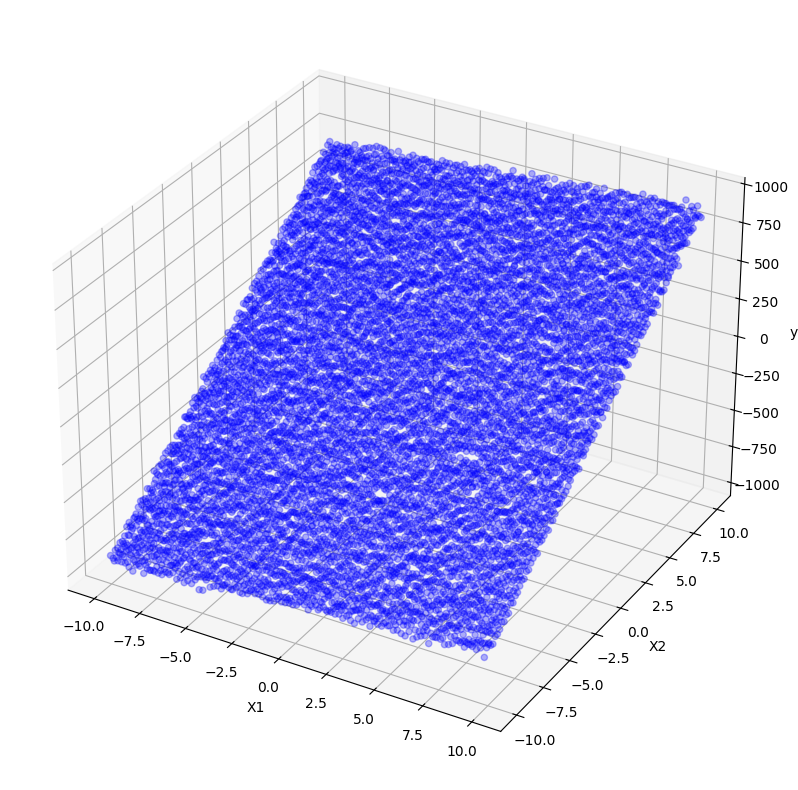

In [95]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_flat, X2_flat, y, c='blue', marker='o', alpha=0.3)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
plt.show()

In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X1_scaled = scaler.fit_transform(X1_flat.reshape(-1, 1)).flatten()
X2_scaled = scaler.fit_transform(X2_flat.reshape(-1, 1)).flatten()
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

print(X1_scaled.shape, X2_scaled.shape, y_scaled.shape)

(10000,) (10000,) (10000,)


In [97]:
print(y_scaled[:10:])


[-1.84148082 -1.90268045 -1.88324624 -1.88195994 -1.88179964 -1.92354888
 -1.96465072 -1.86021432 -1.8597497  -1.94657115]


In [98]:
model = Sequential(
    [
        Dense(16, input_shape=(2,), activation=None),
        Dense(1, activation=None)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
model.compile(optimizer='sgd', loss='mse')
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
X_scaled = np.column_stack((X1_scaled, X2_scaled))
print(X_scaled.shape)

(10000, 2)


In [101]:
logs = model.fit(X_scaled, y_scaled, epochs=10)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0098
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018


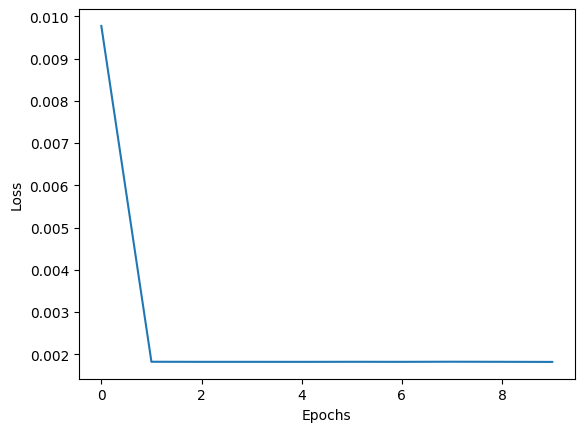

In [102]:
plt.plot(logs.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [103]:
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [104]:
print(y_pred.shape)

(10000, 1)


In [105]:
y_pred = y_pred.flatten()
print(y_pred.shape)

(10000,)


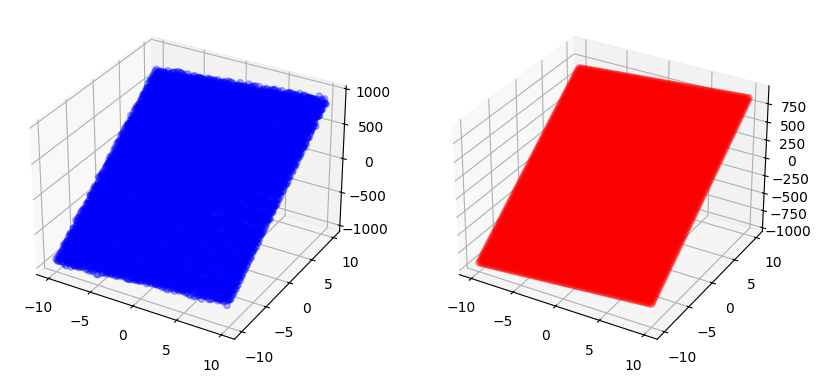

In [106]:
fig = plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1_flat, X2_flat, y, c='blue', marker='o', alpha=0.3)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X1_flat, X2_flat, y_pred, c='red', marker='o', alpha=0.3)

plt.show()

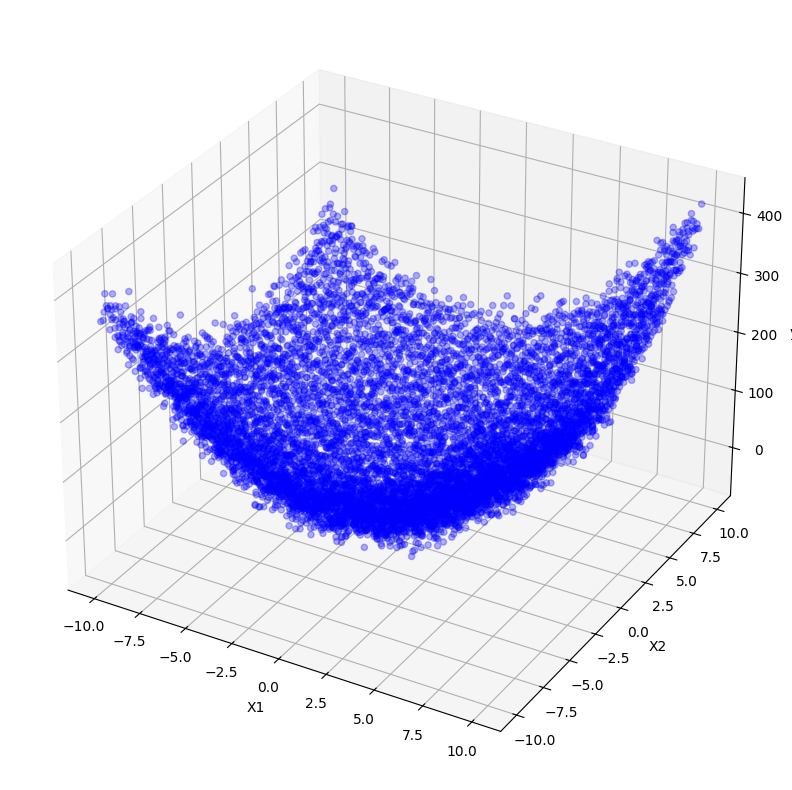

In [107]:
# BT: y = 2*X1^2 + 1.5X2^2 + 0.5*X1*X2 + 3X1 - 2X2 + 1
y = 2*X1_flat**2 + 1.5*X2_flat**2 + 0.5*X1_flat*X2_flat + 3*X1_flat - 2*X2_flat + 1 + np.random.normal(0, 20, len(X1_flat))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_flat, X2_flat, y, c='blue', marker='o', alpha=0.3)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
plt.show()

In [108]:
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

model = Sequential(
    [
        Dense(64, input_shape=(2,), activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation=None)
    ]
)
model.compile(optimizer='sgd', loss='mse')
logs = model.fit(X_scaled, y_scaled, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4946
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1049
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0755
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0690
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0654
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0631
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0615
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0605
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0598
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0593


In [109]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,419 (17.27 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

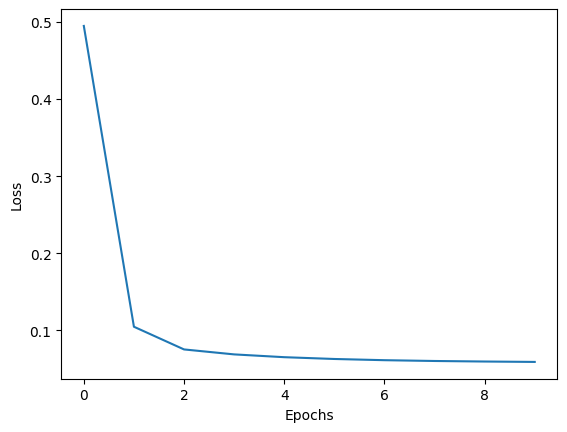

In [110]:
plt.plot(logs.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


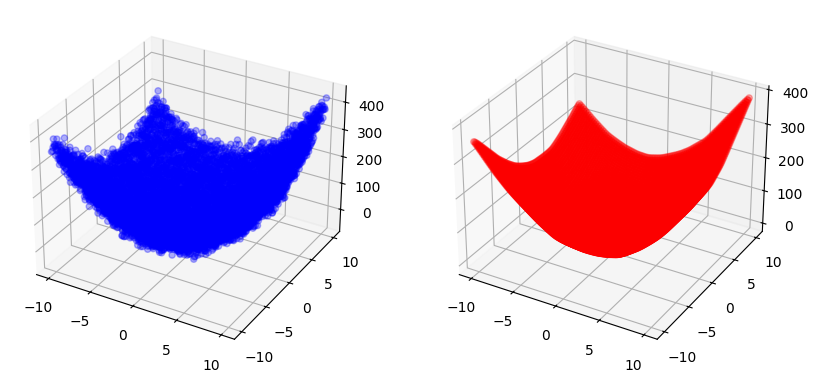

In [111]:
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_pred = y_pred.flatten()


fig = plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1_flat, X2_flat, y, c='blue', marker='o', alpha=0.3)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X1_flat, X2_flat, y_pred, c='red', marker='o', alpha=0.3)

plt.show()

In [121]:
import pandas as pd
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

In [122]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [123]:
df_red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [124]:
df_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [125]:
df_white.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [126]:
from sklearn.utils import resample

df_red_resample = resample(df_red, replace=True, n_samples=len(df_white), random_state=42).reset_index(drop=True)
df_red_resample.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,8.300653,0.526572,0.271143,2.551439,0.087051,15.816047,46.097183,0.996716,3.311837,0.661543,10.462012,5.645978
std,1.730988,0.177378,0.195221,1.441464,0.045575,10.502207,32.594458,0.001869,0.152422,0.173595,1.066214,0.823898
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995540,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079500,14.000000,37.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.740000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [127]:
df_white['color'] = 1
df_red_resample['color'] = 0

df_wine = pd.concat([df_white, df_red_resample], axis=0).reset_index(drop=True)
df_wine.shape

(9796, 13)

In [132]:
y = df_wine['quality'].apply(lambda x: 1 if x >= 6.0 else 0)
y.head(5)

,quality
0,1
1,1
2,1
3,1
4,1


In [129]:
X = df_wine.drop(columns=['quality'], axis=1)
X.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,1


In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)


In [134]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(X_train_scaled.shape, X_test_scaled.shape)

(7836, 12) (1960, 12)


In [135]:
model = Sequential(
    [
        Dense(64, input_shape=(12,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [136]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
logs = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7993 - loss: 0.4281 - val_accuracy: 0.8202 - val_loss: 0.4120
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8003 - loss: 0.4238 - val_accuracy: 0.8163 - val_loss: 0.4077
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8033 - loss: 0.4205 - val_accuracy: 0.8138 - val_loss: 0.4121
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8093 - loss: 0.4152 - val_accuracy: 0.8202 - val_loss: 0.4113
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8097 - loss: 0.4112 - val_accuracy: 0.8291 - val_loss: 0.4068
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8125 - loss: 0.4071 - val_accuracy: 0.8151 - val_loss: 0.4086
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8113 - loss: 0.4058 - val_accuracy: 0.8227 - val_loss: 0.4061
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8152 - loss: 0.4014 - val_ac

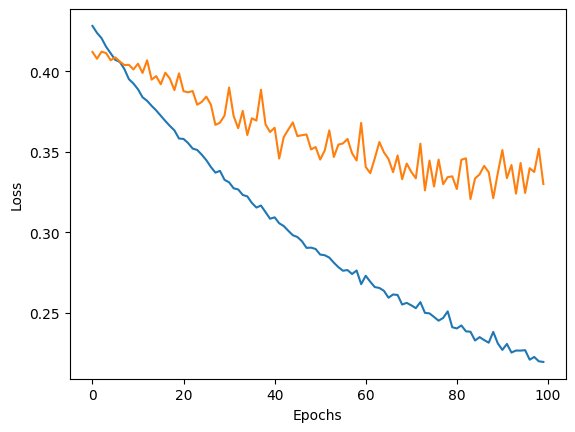

In [139]:
plt.plot(logs.history['loss'])
plt.plot(logs.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [140]:
y_pred = model.predict(X_test_scaled)
print(np.column_stack((y_pred[:5], y_test[:5])))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.7410385  0.        ]
 [0.97813225 1.        ]
 [0.1195398  0.        ]
 [0.98499542 1.        ]
 [0.70078856 1.        ]]


In [141]:
from sklearn.metrics import accuracy_score

print('Accuracy: ', accuracy_score(y_test, np.round(y_pred).reshape(-1)))

Accuracy:  0.8520408163265306
